# ADP Offline Training — Approximate Policy Iteration (API)

We train a **time-dependent strictly linear Value Function Approximation (VFA)**:
$$\hat{V}_t(x_t;\, \boldsymbol{\eta}_t) = \boldsymbol{w}_t^\top \phi(x_t) + b_t$$

using **Approximate Policy Iteration (API)** with $N_{\text{outer}} = 25$ outer iterations,
$N_{\text{samples}} = 50$ trajectories per forward pass, and $N_{\text{inner}} = 5$ policy-evaluation sweeps:

1. **Forward pass** — simulate the current greedy policy over 50 randomly drawn historical
   scenarios with randomised initial physical states to cover the operational state space.
2. **Inner loop** ($N_{\text{inner}} = 5$ backward sweeps) — for $t = T{-}1,\ldots,0$,
   solve a 1-step MILP under the certainty-equivalence principle to obtain Bellman targets
   $V^*(x_{n,t})$, fit $(\boldsymbol{w}_t, b_t)$ by Ridge regression with intercept,
   and update via **Polyak averaging**:
   $\boldsymbol{\eta}_t \leftarrow (1{-}\beta)\,\boldsymbol{\eta}_t + \beta\,\hat{\boldsymbol{\eta}}_t$
   with $\beta = 0.25$.
3. **Export** — save all weights and intercepts to `output/adp_weights.json`.

### Feature vector $\phi(x_t) \in \mathbb{R}^{8}$ — normalised to $[-1,\,1]$

| Index | Feature | Formula | Baseline | Scale | Rationale |
|-------|---------|---------|----------|-------|-----------|
| 0 | $T_1$ | $(T_1 - 22)/8$ | 22 °C | 8 °C | Comfort target; range $[18,26]$ maps to $[-0.5, 0.5]$ |
| 1 | $T_2$ | $(T_2 - 22)/8$ | 22 °C | 8 °C | Same as $T_1$ |
| 2 | $H$ | $(H - 40)/40$ | 40 % | 40 % | Nominal humidity; override at $H_{\text{high}}$ |
| 3 | $\lambda_t$ | $\lambda_t / 10$ | — | 10 €/kWh | Price range $[0,12]$ maps to $[0,1.2]$ |
| 4 | $\lambda_{t-1}$ | $\lambda_{t-1} / 10$ | — | 10 €/kWh | Serial-correlation signal for AR price process |
| 5 | $\text{occ}_1$ | $(\text{occ}_1 - 30)/30$ | 30 pax | 30 | Centred at midpoint of room-1 occupancy range |
| 6 | $\text{occ}_2$ | $(\text{occ}_2 - 20)/20$ | 20 pax | 20 | Centred at midpoint of room-2 occupancy range |
| 7 | $c$ | $c/3$ | — | 3 | Ventilation inertia counter; $c \in \{0,1,2\}$ maps to $[0, 2/3]$ |

The Ridge intercept $b_t$ is fitted with `fit_intercept=True` and stored as the 9th component
`eta[t][8]`, giving a **9-vector** per timestep.

### Certainty-equivalence principle

Because $\hat{V}$ is strictly linear in the physical state $(T_1, T_2, H, c)$ and the
transition dynamics are affine in the exogenous variables $(\text{occ}_1, \text{occ}_2, \lambda)$,
Jensen's inequality holds with equality:
$$\mathbb{E}\bigl[\hat{V}_{t+1}(x_{t+1})\bigr] = \hat{V}_{t+1}\!\bigl(\mathbb{E}[x_{t+1}]\bigr).$$
Substituting expected next-period values converts the stochastic look-ahead into a deterministic
**single-scenario MILP** — one binary variable, linear objective, linear constraints — which
Gurobi solves in milliseconds.  The conditional expectations $\mathbb{E}[\lambda_{t+1}]$ and
$\mathbb{E}[\text{occ}_{t+1}]$ are computed via $K = 50$ Monte Carlo draws from the actual
stochastic process models, correcting the momentum-induced bias of a naive global-mean substitution.

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import pyomo.environ as pyo
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))
import v2_SystemCharacteristics as sc

raw = sc.get_fixed_data()

params = {
    'P_max'    : raw['heating_max_power'],
    'P_vent'   : raw['ventilation_power'],
    'T_low'    : raw['temp_min_comfort_threshold'],
    'T_ok'     : raw['temp_OK_threshold'],
    'T_high'   : raw['temp_max_comfort_threshold'],
    'H_high'   : raw['humidity_threshold'],
    'zeta_exch': raw['heat_exchange_coeff'],
    'zeta_loss': raw['thermal_loss_coeff'],
    'zeta_conv': raw['heating_efficiency_coeff'],
    'zeta_cool': raw['heat_vent_coeff'],
    'zeta_occ' : raw['heat_occupancy_coeff'],
    'eta_occ'  : raw['humidity_occupancy_coeff'],
    'eta_vent' : raw['humidity_vent_coeff'],
    'T_out'    : raw['outdoor_temperature'],
}

T_INIT = float(raw['T1'])   # 21.0 °C
H_INIT = float(raw['H'])    # 40.0 %
T      = 10


# ---------------------------------------------------------------------------
# Stochastic process models — inlined to avoid matplotlib side-effects from
# importing PriceProcessRestaurant.py at module level.
# These must match PriceProcessRestaurant.price_model and
# OccupancyProcessRestaurant.next_occupancy_levels exactly.
# ---------------------------------------------------------------------------
def _price_model(current_price: float, previous_price: float) -> float:
    """One-step AR price process with mean-reversion to 4 €/kWh."""
    next_p = (current_price
              + 0.6 * (current_price - previous_price)
              + 0.12 * (4.0 - current_price)
              + np.random.normal(0, 0.5))
    if next_p < 0 and np.random.rand() > 0.2:
        next_p = np.random.uniform(0, 1.2)   # 4 * 0.3 = 1.2
    return float(np.clip(next_p, 0.0, 12.0))


def _next_occupancy(r1: float, r2: float):
    """One-step Markov occupancy process for both rooms."""
    r1_next = r1 + 0.25 * (35.0 - r1) + 0.1 * (r2 - r1) + np.random.normal(0, 3.0)
    r2_next = r2 + 0.25 * (25.0 - r2) + 0.1 * (r1 - r2) + np.random.normal(0, 2.5)
    return float(np.clip(r1_next, 20, 50)), float(np.clip(r2_next, 10, 30))


print("System parameters loaded.")
print(f"  T_low={params['T_low']} | T_ok={params['T_ok']} | T_high={params['T_high']} | H_high={params['H_high']}")
print(f"  P_max={params['P_max']} kW | P_vent={params['P_vent']} kW")
print("  _price_model and _next_occupancy defined (inlined from process files).")

System parameters loaded.
  T_low=18.0 | T_ok=22.0 | T_high=26.0 | H_high=70.0
  P_max=3.0 kW | P_vent=2.0 kW
  _price_model and _next_occupancy defined (inlined from process files).


In [2]:
price_df = pd.read_csv('v2_PriceData.csv', header=0)
occ1_df  = pd.read_csv('OccupancyRoom1.csv', header=0)
occ2_df  = pd.read_csv('OccupancyRoom2.csv', header=0)

# v2_PriceData.csv: col0 = previous price, cols '1'..'10' = price at t=0..9
# OccupancyRoomX.csv: cols '0'..'9' = occupancy at t=0..9
price_cols = [str(i) for i in range(1, 11)]
occ_cols   = [str(i) for i in range(10)]

prices_all  = price_df[price_cols].values.astype(float)   # (N, 10)
prev_prices = price_df.iloc[:, 0].values.astype(float)    # (N,)
occ1_all    = occ1_df[occ_cols].values.astype(float)      # (N, 10)
occ2_all    = occ2_df[occ_cols].values.astype(float)      # (N, 10)

N = len(prices_all)
print(f"Loaded {N} days of historical data.")
print(f"  Price range: [{prices_all.min():.2f}, {prices_all.max():.2f}] euro/kWh")
print(f"  Occ1  range: [{occ1_all.min():.1f}, {occ1_all.max():.1f}] persons")
print(f"  Occ2  range: [{occ2_all.min():.1f}, {occ2_all.max():.1f}] persons")

Loaded 100 days of historical data.
  Price range: [0.00, 12.00] euro/kWh
  Occ1  range: [20.5, 47.5] persons
  Occ2  range: [14.1, 30.0] persons


In [3]:
N_FEAT = 8   # explicit features; Ridge intercept is stored separately as eta[8]

# K_MC: Monte Carlo draws from the actual stochastic process models used to
# compute state-conditional expected next-period values for the Bellman targets.
K_MC = 50


def phi(state: dict) -> np.ndarray:
    """
    Compute the 8-dimensional normalised feature vector phi(x_t).

    The feature mapping is designed so that each component lies in
    approximately [-1, 1] under normal operating conditions, ensuring
    numerical stability of the Ridge regression during offline training
    and well-conditioned MILP coefficients during online optimisation.

    The Ridge intercept b_t is fitted separately by Ridge(fit_intercept=True)
    during training and stored as eta[t][8]; it is NOT included in the
    returned array.  The Certainty-Equivalence property:

        E_w[ phi( f(x, u, w) ) ] = phi( f(x, u, E[w]) )

    holds exactly for this strictly linear feature mapping because all
    phi components are affine in the state variables.

    This function MUST match ADP_policy_14.py._phi() exactly.

      idx  feature        formula               baseline  scale
       0   T1             (T1   - 22) / 8       22 °C     8 °C
       1   T2             (T2   - 22) / 8       22 °C     8 °C
       2   H              (H    - 40) / 40       40 %      40 %
       3   price           price / 10            0         10 €/kWh
       4   price_prev      price_prev / 10       0         10 €/kWh
       5   occ1           (occ1 - 30) / 30       30 pax    30
       6   occ2           (occ2 - 20) / 20       20 pax    20
       7   c               c / 3                 0         3

    Parameters
    ----------
    state : dict
        State dictionary.  Required key: 'T1', 'T2', 'price'.
        Optional keys default to 0 / current price if absent.

    Returns
    -------
    np.ndarray of shape (8,)
    """
    T1         = float(state['T1'])
    T2         = float(state['T2'])
    H          = float(state.get('H', 0.0))
    price      = float(state['price'])
    price_prev = float(state.get('price_previous', price))
    occ1       = float(state.get('occ1', 0.0))
    occ2       = float(state.get('occ2', 0.0))
    c          = float(state.get('c', 0))

    return np.array([
        (T1         - 22.0) /  8.0,   # idx 0 — room-1 temperature
        (T2         - 22.0) /  8.0,   # idx 1 — room-2 temperature
        (H          - 40.0) / 40.0,   # idx 2 — relative humidity
         price               / 10.0,  # idx 3 — current electricity price
         price_prev          / 10.0,  # idx 4 — lagged price (AR signal)
        (occ1       - 30.0) / 30.0,   # idx 5 — room-1 occupancy
        (occ2       - 20.0) / 20.0,   # idx 6 — room-2 occupancy
         c                  /  3.0,   # idx 7 — ventilation inertia counter
    ], dtype=float)


# Sanity checks
s_test = {'T1': 22.0, 'T2': 20.0, 'H': 55.0, 'c': 1,
          'price': 8.0, 'price_previous': 3.0, 'occ1': 35.0, 'occ2': 15.0}
print("phi(nominal) =", np.round(phi(s_test), 4))

s_cold = {'T1': 18.0, 'T2': 19.0, 'H': 40.0, 'c': 0,
          'price': 5.0, 'price_previous': 5.0, 'occ1': 30.0, 'occ2': 20.0}
print("phi(cold)    =", np.round(phi(s_cold), 4), "  <- T1, T2 features should be negative")

s_init = {'T1': 21.0, 'T2': 21.0, 'H': 40.0, 'c': 0,
          'price': 5.0, 'price_previous': 5.0, 'occ1': 30.0, 'occ2': 20.0}
print("phi(init)    =", np.round(phi(s_init), 4), "  <- initial state at system start")

print(f"\nN_FEAT={N_FEAT}  K_MC={K_MC}")
print("Intercept b_t stored as eta[t][8] — fitted separately by Ridge(fit_intercept=True).")


phi(nominal) = [ 0.     -0.25    0.375   0.8     0.3     0.1667 -0.25    0.3333]
phi(cold)    = [-0.5   -0.375  0.     0.5    0.5    0.     0.     0.   ]   <- T1, T2 features should be negative
phi(init)    = [-0.125 -0.125  0.     0.5    0.5    0.     0.     0.   ]   <- initial state at system start

N_FEAT=8  K_MC=50
Intercept b_t stored as eta[t][8] — fitted separately by Ridge(fit_intercept=True).


In [4]:
def apply_dynamics(state, decisions):
    """One-step transition — mirrors Task6_Environment.apply_dynamics exactly."""
    p  = params
    t  = int(state['current_time'])
    p1 = float(decisions['HeatPowerRoom1'])
    p2 = float(decisions['HeatPowerRoom2'])
    v  = int(float(decisions['VentilationON']) > 0.5)
    H  = float(state.get('H', 0.0))
    c  = int(state.get('c', 0))

    # Overrule controllers (mandatory)
    if c > 0:                 v  = 1
    if H >= p['H_high']:      v  = 1
    if state.get('y_low_1'):  p1 = p['P_max']
    if state.get('y_low_2'):  p2 = p['P_max']
    if state.get('y_high_1'): p1 = 0.0
    if state.get('y_high_2'): p2 = 0.0

    step_cost = float(state['price']) * (p1 + p2 + p['P_vent'] * v)

    T_out = float(p['T_out'][min(t, 9)])
    T1    = float(state['T1']);  T2   = float(state['T2'])
    occ1  = float(state.get('occ1', 0.0));  occ2 = float(state.get('occ2', 0.0))

    T1_n = (T1 + p['zeta_exch']*(T2 - T1) + p['zeta_loss']*(T_out - T1)
            + p['zeta_conv']*p1 - p['zeta_cool']*v + p['zeta_occ']*occ1)
    T2_n = (T2 + p['zeta_exch']*(T1 - T2) + p['zeta_loss']*(T_out - T2)
            + p['zeta_conv']*p2 - p['zeta_cool']*v + p['zeta_occ']*occ2)
    H_n  = max(0.0, H + p['eta_occ']*(occ1 + occ2) - p['eta_vent']*v)
    c_n  = (2 if c == 0 else max(0, c - 1)) if v == 1 else 0

    y_lo1 = (1 if T1_n < p['T_low'] else
             (0 if T1_n >= p['T_ok'] else int(state.get('y_low_1', 0))))
    y_lo2 = (1 if T2_n < p['T_low'] else
             (0 if T2_n >= p['T_ok'] else int(state.get('y_low_2', 0))))
    y_hi1 = 1 if T1_n > p['T_high'] else 0
    y_hi2 = 1 if T2_n > p['T_high'] else 0

    return {
        'T1': T1_n, 'T2': T2_n, 'H': H_n, 'c': c_n,
        'y_low_1': y_lo1, 'y_low_2': y_lo2,
        'y_high_1': y_hi1, 'y_high_2': y_hi2,
        'occ1': occ1, 'occ2': occ2,
        'price': float(state['price']),
        'price_previous': float(state['price']),
        'current_time': t + 1,
    }, step_cost


def heuristic_policy(state: dict) -> dict:
    """
    Reactive heuristic for the first-iteration forward pass.

    Heats room r when its temperature is below T_ok − 1 °C = 21 °C,
    ensuring the forward pass generates states near the lower comfort
    boundary where the VFA must be accurate.  Ventilates when the
    inertia counter requires it (c > 0), the humidity override is active
    (H ≥ H_high), or humidity is moderately elevated (H > 55 %).
    """
    p  = params
    T1 = float(state['T1']);  T2 = float(state['T2'])
    H  = float(state.get('H', 0.0));  c = int(state.get('c', 0))

    v = 1 if (c > 0 or H >= p['H_high']) else int(H > 55.0)

    def heat_power(T_r, y_lo, y_hi):
        if y_hi: return 0.0
        if y_lo: return p['P_max']
        return p['P_max'] if T_r < (p['T_ok'] - 1.0) else 0.0

    return {
        'HeatPowerRoom1': heat_power(T1, state.get('y_low_1', 0), state.get('y_high_1', 0)),
        'HeatPowerRoom2': heat_power(T2, state.get('y_low_2', 0), state.get('y_high_2', 0)),
        'VentilationON' : v,
    }

print("apply_dynamics and heuristic_policy defined.")

apply_dynamics and heuristic_policy defined.


## Step 1 — Forward Pass

Simulate the current policy over all $N$ historical scenarios.
Each scenario uses the fixed initial physical state $(T^{\mathrm{init}}, H^{\mathrm{init}})$
with the realised historical prices and occupancies.
The first outer iteration uses the reactive heuristic; subsequent iterations use
the current greedy ADP policy.

In [5]:
N_SAMPLES = 50   # trajectories per forward pass


def run_forward_pass(policy_fn) -> list:
    """
    Simulate policy_fn over N_SAMPLES randomly drawn trajectories.

    Design choices for training diversity and OLS identifiability:

    1. Random day selection from the N=100 historical CSV scenarios (with
       replacement) provides diverse price/occupancy sequences without
       requiring a stochastic process model.

    2. Randomised initial physical state (T1, T2 in [17.5, 23.5] °C;
       H in [30, 60] %) ensures the regression sees states well below the
       19.5 °C hockey-stick threshold, where the penalty VFA must be accurate.

    3. Exploratory initial discrete state: c drawn from {0, 1, 2} and
       y_low_1/y_low_2 drawn from {0, 1} via np.random.choice.
       CRITICAL: deterministic initialisation (c=0, y_low=0 for all n)
       creates a zero-variance column in the feature matrix at t=0,
       which destroys the regression gradient for the c feature and
       produces large erratic coefficients.  Random initialisation
       eliminates this degeneracy while staying within the physically
       reachable state space.

    Returns
    -------
    states_out : list[list[dict]]
        states_out[t][n] is the state dict at time t for trajectory n.
    """
    states_out  = [[None] * N_SAMPLES for _ in range(T)]
    day_indices = np.random.choice(N, N_SAMPLES, replace=True)

    for n, di in enumerate(day_indices):
        T1_0    = np.random.uniform(17.5, 23.5)
        T2_0    = np.random.uniform(17.5, 23.5)
        H_0     = np.random.uniform(30.0, 60.0)
        c_0     = int(np.random.choice([0, 1, 2]))
        y_lo1_0 = int(np.random.choice([0, 1]))
        y_lo2_0 = int(np.random.choice([0, 1]))

        state = {
            'T1': T1_0, 'T2': T2_0, 'H': H_0,
            'c': c_0, 'y_low_1': y_lo1_0, 'y_low_2': y_lo2_0,
            'y_high_1': 0, 'y_high_2': 0,
            'occ1'          : float(occ1_all[di, 0]),
            'occ2'          : float(occ2_all[di, 0]),
            'price'         : float(prices_all[di, 0]),
            'price_previous': float(prev_prices[di]),
            'current_time'  : 0,
        }
        for t in range(T):
            state['price']          = float(prices_all[di, t])
            state['price_previous'] = (float(prices_all[di, t - 1]) if t > 0
                                       else float(prev_prices[di]))
            state['occ1']           = float(occ1_all[di, t])
            state['occ2']           = float(occ2_all[di, t])
            state['current_time']   = t
            states_out[t][n] = dict(state)
            state, _ = apply_dynamics(state, policy_fn(state))

    return states_out


print(f"run_forward_pass: N_SAMPLES={N_SAMPLES}, T1/T2 in [17.5, 23.5] °C, H in [30,60] %.")
print("  Exploratory init: c ~ {0,1,2}, y_low ~ {0,1} — ensures OLS identifiability at t=0.")

run_forward_pass: N_SAMPLES=50, T1/T2 in [17.5, 23.5] °C, H in [30,60] %.
  Exploratory init: c ~ {0,1,2}, y_low ~ {0,1} — ensures OLS identifiability at t=0.


## Step 2 — Backward Pass + Ridge Regression

For each inner sweep, iterate backwards over $t = T{-}1, \ldots, 0$:

$$V^*(x_{n,t}) = \min_{p_1,\,p_2,\,v}\Bigl\{\lambda_{n,t}(p_1+p_2+P_{\text{vent}}\,v) + \hat{V}_{t+1}\!\bigl(\mathbb{E}[x_{t+1}(p_1,p_2,v)]\bigr)\Bigr\}$$

where $\mathbb{E}[x_{t+1}]$ is obtained by substituting expected next-period exogenous values into the deterministic dynamics — a valid substitution because both $\hat{V}_{t+1}$ and the dynamics are strictly linear in $(\text{occ}_1, \text{occ}_2, \lambda)$.

Then fit $\hat{\eta}_t$ by **Ridge regression** on $(\Phi_t,\, V^*_t)$:
$$\hat{\eta}_t = \arg\min_\eta \bigl\|\Phi_t\,\eta - V^*_t\bigr\|^2 + \alpha\|\eta\|^2, \quad \alpha = 1.$$

**Within-pass bootstrap**: the just-fitted $\hat{\eta}_{t+1}$ is used immediately for step $t$, propagating information backward within each sweep.

**Terminal condition**: $\hat{V}_T \equiv 0$ (zero continuation value after the last period).

In [6]:
BIG_M = 1_000


def solve_1step(state: dict, eta_next: np.ndarray,
                return_action: bool = False):
    """
    One-period MILP with state-conditional Monte Carlo look-ahead.

    Solves the Bellman optimality equation for one timestep under the
    Certainty-Equivalence (CE) principle:

        min_{p1, p2, v}  price * (p1 + p2 + P_vent * v)
                       + V_hat_{t+1}( E[x_{t+1} | x_t, p1, p2, v] )
                       + overrule_penalty

    The conditional expectations E[price_{t+1}], E[occ1_{t+1}], E[occ2_{t+1}]
    are computed by drawing K_MC samples from the actual stochastic process
    models conditioned on the current state.  Because V_hat is strictly linear
    in the state, substituting these scalar expectations preserves CE validity
    while correcting the systematic bias that arises from the AR price momentum.

    Design choices
    --------------
    1. K_MC = 50 Monte Carlo draws from real process models for conditional
       Bellman targets.  Conditional means are scalar constants — MILP
       linearity is preserved under the CE substitution.
    2. Cascade penalty applied to Bellman targets when the optimal action
       still leads T_r < T_low (training only; not included in the online MILP).
    3. Big-M soft penalties enforce mandatory overrule actions without adding
       hard equality constraints that would alter the feasible region.

    Parameters
    ----------
    state        : current state dict
    eta_next     : weight vector for t+1  (length N_FEAT+1 = 9; eta_next[8] = intercept)
    return_action: True  -> return the optimal decision dict
                   False -> return the Bellman target scalar for regression

    Returns
    -------
    dict   (HeatPowerRoom1, HeatPowerRoom2, VentilationON) if return_action is True
    float  Bellman target V*(x_t)                           if return_action is False
    None   on solver failure
    """
    p      = params
    P_max  = p['P_max']
    t      = int(state.get('current_time', 0))
    T_out  = float(p['T_out'][min(t, 9)])
    T1     = float(state['T1'])
    T2     = float(state['T2'])
    H      = float(state.get('H', 0.0))
    c      = int(state.get('c', 0))
    occ1   = float(state.get('occ1', 0.0))
    occ2   = float(state.get('occ2', 0.0))
    price  = float(state['price'])
    price_prev = float(state.get('price_previous', price))
    eta    = eta_next

    # -- Conditional expectations via K_MC draws from actual process models --
    mc_prices = [_price_model(price, price_prev) for _ in range(K_MC)]
    mc_occs   = [_next_occupancy(occ1, occ2)     for _ in range(K_MC)]

    cond_price_next = float(np.mean(mc_prices))
    cond_occ1_next  = float(np.mean([o[0] for o in mc_occs]))
    cond_occ2_next  = float(np.mean([o[1] for o in mc_occs]))

    m = pyo.ConcreteModel()

    # Decision variables
    m.p1 = pyo.Var(bounds=(0, P_max))
    m.p2 = pyo.Var(bounds=(0, P_max))
    m.v  = pyo.Var(domain=pyo.Binary)

    # Post-decision state variables (auxiliary, linear in decisions)
    m.T1x = pyo.Var()
    m.T2x = pyo.Var()
    m.Hx  = pyo.Var()

    # Transition dynamics using the realised current occupancy
    m.dT1 = pyo.Constraint(expr=
        m.T1x == T1 + p['zeta_exch'] * (T2 - T1)
               + p['zeta_loss'] * (T_out - T1)
               + p['zeta_conv'] * m.p1
               - p['zeta_cool'] * m.v
               + p['zeta_occ']  * occ1)
    m.dT2 = pyo.Constraint(expr=
        m.T2x == T2 + p['zeta_exch'] * (T1 - T2)
               + p['zeta_loss'] * (T_out - T2)
               + p['zeta_conv'] * m.p2
               - p['zeta_cool'] * m.v
               + p['zeta_occ']  * occ2)
    m.dH = pyo.Constraint(expr=
        m.Hx == H
              + p['eta_occ']  * (occ1 + occ2)
              - p['eta_vent'] * m.v)

    # Ventilation inertia counter: normalised c_next / 3, linear in v.
    #   c = 0 (free):   c_next = 2*v       => c_next/3 = (2/3)*v
    #   c = 1 (forced): c_next = 0         => c_next/3 = 0
    #   c = 2 (forced): c_next = 1         => c_next/3 = 1/3
    if   c == 0: c_next_norm = (2.0 / 3.0) * m.v
    elif c == 1: c_next_norm = 0.0
    else:        c_next_norm = 1.0 / 3.0

    # Big-M soft overrule penalties
    penalty_terms = []
    if c > 0 or H >= p['H_high']:
        penalty_terms.append(BIG_M * (1 - m.v))
    if state.get('y_low_1'):
        penalty_terms.append(BIG_M * (P_max - m.p1))
    if state.get('y_low_2'):
        penalty_terms.append(BIG_M * (P_max - m.p2))
    if state.get('y_high_1'):
        penalty_terms.append(BIG_M * m.p1)
    if state.get('y_high_2'):
        penalty_terms.append(BIG_M * m.p2)
    overrule_penalty = sum(penalty_terms) if penalty_terms else 0.0

    # VFA of the expected next state:
    #   phi(E[x_{t+1}])^T * eta[:8]  +  eta[8]
    #
    # Features 0-2 and 7 are Pyomo affine expressions (linear in p1, p2, v).
    # Features 3-6 are scalar constants substituted via the CE principle.
    vfa_next = (
        eta[8]                                                   +  # Ridge intercept
        eta[0] * ((m.T1x          - 22.0) /  8.0)               +  # T1 feature
        eta[1] * ((m.T2x          - 22.0) /  8.0)               +  # T2 feature
        eta[2] * ((m.Hx           - 40.0) / 40.0)               +  # humidity
        eta[3] * ( cond_price_next          / 10.0)              +  # E[price_next]
        eta[4] * ( price                    / 10.0)              +  # price_prev signal
        eta[5] * ((cond_occ1_next  - 30.0) / 30.0)              +  # E[occ1_next]
        eta[6] * ((cond_occ2_next  - 20.0) / 20.0)              +  # E[occ2_next]
        eta[7] *  c_next_norm                                       # inertia counter
    )

    m.obj = pyo.Objective(
        expr=price * (m.p1 + m.p2 + p['P_vent'] * m.v) + vfa_next + overrule_penalty,
        sense=pyo.minimize)

    solver = pyo.SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0

    try:
        result = solver.solve(m)
    except Exception as exc:
        print(f"PYOMO CRASHED: {exc}")
        return None

    if result.solver.termination_condition != pyo.TerminationCondition.optimal:
        return None

    p1_val = float(pyo.value(m.p1))
    p2_val = float(pyo.value(m.p2))
    v_val  = int(round(pyo.value(m.v)))

    if return_action:
        return {'HeatPowerRoom1': p1_val, 'HeatPowerRoom2': p2_val,
                'VentilationON' : v_val}

    # -- Bellman target: immediate cost + MC-averaged VFA + cascade penalty --
    T1x_val = float(pyo.value(m.T1x))
    T2x_val = float(pyo.value(m.T2x))
    Hx_val  = float(pyo.value(m.Hx))
    c_next  = (2 if c == 0 else max(0, c - 1)) if v_val == 1 else 0
    immediate = price * (p1_val + p2_val + p['P_vent'] * v_val)

    # Cascade penalty encourages the VFA to encode multi-step recovery cost
    # when the optimal single-step action still leads T_r below T_low (18 °C).
    # Applied only to the regression targets, not to the online MILP objective.
    _T_low  = float(p['T_low'])
    _N_CASC = 3.0
    casc_penalty = 0.0
    if T1x_val < _T_low:
        casc_penalty += _N_CASC * cond_price_next * P_max * (_T_low - T1x_val)
    if T2x_val < _T_low:
        casc_penalty += _N_CASC * cond_price_next * P_max * (_T_low - T2x_val)

    # Average VFA over K_MC next-state draws (necessary because phi is
    # evaluated at stochastic exogenous realisations during training).
    vfa_acc = 0.0
    for k in range(K_MC):
        next_mc = {
            'T1': T1x_val, 'T2': T2x_val, 'H': Hx_val, 'c': c_next,
            'price'         : mc_prices[k],
            'price_previous': price,
            'occ1'          : mc_occs[k][0],
            'occ2'          : mc_occs[k][1],
        }
        vfa_acc += float(np.dot(phi(next_mc), eta[:N_FEAT]) + eta[N_FEAT])
    return immediate + vfa_acc / K_MC + casc_penalty


print("solve_1step defined.")
print(f"  CE substitution with K_MC={K_MC} conditional MC draws.")
print("  Bellman target averages VFA over K_MC next-state draws.")
print("  Cascade penalty (N_CASC=3.0) applied in training targets only.")


solve_1step defined.
  CE substitution with K_MC=50 conditional MC draws.
  Bellman target averages VFA over K_MC next-state draws.
  Cascade penalty (N_CASC=3.0) applied in training targets only.


In [7]:
from sklearn.linear_model import Ridge

# ── API hyperparameters ───────────────────────────────────────────────────────
N_OUTER = 25    # outer API iterations (forward pass + inner sweeps)
N_INNER =  5    # inner policy-evaluation sweeps per outer iteration
BETA    = 0.25  # Polyak averaging rate: eta <- (1-BETA)*eta_old + BETA*eta_fitted

# Weight matrix: shape (T+1, N_FEAT+1) = (11, 9)
# Columns 0..7: Ridge coefficients for phi features; column 8: Ridge intercept.
# Row T is held at zero throughout (terminal boundary condition: V_T = 0).
eta_all = np.zeros((T + 1, N_FEAT + 1))


def run_backward_pass(states: list, verbose: bool = False) -> np.ndarray:
    """
    Perform one complete backward sweep and return the fitted weight matrix.

    For t = T-1 down to 0:

      1. Solve solve_1step(x_{n,t}, eta_{t+1}) for each trajectory n to obtain
         the Bellman target V*(x_{n,t}).
      2. Assemble the feature matrix Phi (N_SAMPLES x N_FEAT) and target
         vector y (N_SAMPLES,).
      3. Fit Ridge(alpha=1.0, fit_intercept=True) on (Phi, y).
      4. Store [coef_, intercept_] as eta_new[t] (length N_FEAT+1 = 9).

    Within-pass bootstrap: the just-fitted eta_new[t+1] is used immediately
    as the continuation weight for step t, propagating information backward
    within each sweep.

    Terminal boundary condition: eta_new[T] = 0 (zero continuation value
    after the last decision epoch).

    Parameters
    ----------
    states  : list[list[dict]] — states[t][n] is the state dict at (t, n)
    verbose : print per-timestep diagnostics on the final inner sweep

    Returns
    -------
    eta_new : np.ndarray of shape (T+1, N_FEAT+1)
    """
    eta_new = np.zeros((T + 1, N_FEAT + 1))   # row T = 0 (terminal condition)

    for t in range(T - 1, -1, -1):
        eta_next = eta_new[t + 1]              # within-pass bootstrap
        targets, rows, n_skip = [], [], 0

        for n in range(N_SAMPLES):
            v_star = solve_1step(states[t][n], eta_next)
            if v_star is None or not np.isfinite(v_star):
                n_skip += 1
                continue
            targets.append(v_star)
            rows.append(phi(states[t][n]))

        n_valid = len(targets)
        if n_valid < N_FEAT + 1:
            # Insufficient valid samples for regression — retain old weights.
            eta_new[t] = eta_all[t]
            if verbose:
                print(f"    t={t}  WARN: only {n_valid} valid samples — kept old weights")
            continue

        Phi   = np.array(rows)
        y     = np.array(targets)
        ridge = Ridge(alpha=1.0, fit_intercept=True)
        ridge.fit(Phi, y)

        eta_new[t] = np.append(ridge.coef_, ridge.intercept_)

        if verbose:
            y_hat = Phi @ ridge.coef_ + ridge.intercept_
            rmse  = float(np.sqrt(np.mean((y_hat - y) ** 2)))
            print(f"    t={t}  n={n_valid}/{N_SAMPLES}  skip={n_skip}"
                  f"  rmse={rmse:8.3f}  |w|∞={np.max(np.abs(ridge.coef_)):.3f}")

    return eta_new


def adp_policy(state: dict) -> dict:
    """
    Greedy one-step lookahead using the current global weight matrix eta_all.
    Falls back to heuristic_policy on solver failure to guarantee feasibility.
    """
    t        = int(state.get('current_time', 0))
    eta_next = eta_all[min(t + 1, T)]
    action   = solve_1step(state, eta_next, return_action=True)
    return action if action is not None else heuristic_policy(state)


# ── Outer API loop ────────────────────────────────────────────────────────────
t_total = time.perf_counter()

for outer in range(N_OUTER):
    policy_fn = heuristic_policy if outer == 0 else adp_policy
    print(f"\n{'='*60}")
    print(f"API ITER {outer+1:>2}/{N_OUTER}  ·  "
          f"{'heuristic (iter 0)' if outer == 0 else 'ADP greedy'}")
    print(f"{'='*60}")

    t_fwd  = time.perf_counter()
    states = run_forward_pass(policy_fn)
    print(f"  Forward done: {time.perf_counter() - t_fwd:.1f}s  ({N_SAMPLES} trajectories)")

    for inner in range(N_INNER):
        verbose  = (inner == N_INNER - 1)
        eta_raw  = run_backward_pass(states, verbose=verbose)
        eta_all  = (1.0 - BETA) * eta_all + BETA * eta_raw

        print(f"  Inner {inner+1}/{N_INNER}"
              f"  max|w|={np.max(np.abs(eta_all[:T, :N_FEAT])):.3f}"
              f"  |b|∞={np.max(np.abs(eta_all[:T, N_FEAT])):.3f}")

elapsed = (time.perf_counter() - t_total) / 60.0
print(f"\nAll {N_OUTER}×{N_INNER} sweeps complete — {elapsed:.1f} min total.")

print(f"\nFinal VFA weights (t = 0 .. {T-1}):")
hdr = (f"{'t':>2}  {'T1':>7}  {'T2':>7}  {'H':>7}  {'price':>7}  {'p_prev':>7}"
       f"  {'occ1':>7}  {'occ2':>7}  {'c':>7}  {'intercept':>12}")
print(hdr)
print("-" * len(hdr))
for ti in range(T):
    e = eta_all[ti]
    print(f"  {ti}  {e[0]:>7.3f}  {e[1]:>7.3f}  {e[2]:>7.3f}  {e[3]:>7.3f}  {e[4]:>7.3f}"
          f"  {e[5]:>7.3f}  {e[6]:>7.3f}  {e[7]:>7.3f}  {e[8]:>12.3f}")



API ITER  1/25  ·  heuristic (iter 0)
  Forward done: 0.0s  (50 trajectories)
  Inner 1/5  max|w|=51.412  |b|∞=6.988
  Inner 2/5  max|w|=90.173  |b|∞=11.899
  Inner 3/5  max|w|=119.027  |b|∞=15.800
  Inner 4/5  max|w|=140.908  |b|∞=18.621
    t=9  n=50/50  skip=0  rmse=  16.516  |w|∞=23.123
    t=8  n=50/50  skip=0  rmse=  20.708  |w|∞=41.226
    t=7  n=50/50  skip=0  rmse=  12.163  |w|∞=51.859
    t=6  n=50/50  skip=0  rmse=  14.329  |w|∞=54.409
    t=5  n=50/50  skip=0  rmse=  11.508  |w|∞=45.512
    t=4  n=50/50  skip=0  rmse=  10.513  |w|∞=48.758
    t=3  n=50/50  skip=0  rmse=  15.702  |w|∞=60.289
    t=2  n=50/50  skip=0  rmse=  22.046  |w|∞=85.327
    t=1  n=50/50  skip=0  rmse=  20.690  |w|∞=121.242
    t=0  n=50/50  skip=0  rmse=  36.776  |w|∞=205.209
  Inner 5/5  max|w|=156.983  |b|∞=20.841

API ITER  2/25  ·  ADP greedy
  Forward done: 6.8s  (50 trajectories)
  Inner 1/5  max|w|=197.544  |b|∞=38.556
  Inner 2/5  max|w|=227.898  |b|∞=51.293
  Inner 3/5  max|w|=250.624  |b|∞=

In [8]:
os.makedirs('output', exist_ok=True)
weights_path = 'output/adp_weights.json'

_nan_count = int(np.sum(~np.isfinite(eta_all)))
if _nan_count > 0:
    print(f"WARNING: Found {_nan_count} NaN/Inf values in eta_all — replacing with 0.0")
    eta_all = np.where(np.isfinite(eta_all), eta_all, 0.0)
else:
    print(f"Weights sanity check OK — all {eta_all.size} values finite.")

weights_dict = {
    'description': (
        f'Time-dependent linear VFA weights for t=0..{T-1}. '
        f'Produced by ADP_policy_14.ipynb (API, N_OUTER={N_OUTER}, '
        f'N_INNER={N_INNER}, N_SAMPLES={N_SAMPLES}, BETA={BETA}, Ridge alpha=1.0). '
        f'8 normalised features + Ridge intercept at index 8: '
        f'(T1-22)/8, (T2-22)/8, (H-40)/40, price/10, price_prev/10, '
        f'(occ1-30)/30, (occ2-20)/20, c/3, intercept.'
    ),
    'feature_names': [
        '(T1-22)/8',
        '(T2-22)/8',
        '(H-40)/40',
        'price/10',
        'price_prev/10',
        '(occ1-30)/30',
        '(occ2-20)/20',
        'c/3',
        'intercept',
    ],
    'eta': {str(t): eta_all[t].tolist() for t in range(T)},
}

with open(weights_path, 'w') as f:
    json.dump(weights_dict, f, indent=2)

print(f"Weights saved -> '{weights_path}'")
print()
hdr = (f"{'t':>2}  {'T1':>7}  {'T2':>7}  {'H':>7}  {'price':>7}  {'p_prev':>7}"
       f"  {'occ1':>7}  {'occ2':>7}  {'c':>7}  {'intercept':>12}")
print(hdr)
print("-" * len(hdr))
for ti in range(T):
    e = eta_all[ti]
    print(f"  {ti}  {e[0]:>7.3f}  {e[1]:>7.3f}  {e[2]:>7.3f}  {e[3]:>7.3f}  {e[4]:>7.3f}"
          f"  {e[5]:>7.3f}  {e[6]:>7.3f}  {e[7]:>7.3f}  {e[8]:>12.3f}")


Weights sanity check OK — all 99 values finite.
Weights saved -> 'output/adp_weights.json'

 t       T1       T2        H    price   p_prev     occ1     occ2        c     intercept
----------------------------------------------------------------------------------------
  0  -31.745  -59.797   17.821  224.220  -46.718   -8.804  -17.091   25.747       108.865
  1  -57.409  -62.792   46.526  165.100   68.982  -35.851  -18.828    5.132        54.571
  2  -45.435  -38.568   33.486  103.892   73.714  -11.256   -3.291    8.322        61.718
  3  -43.094  -45.927   32.392   73.828   61.175    2.781    0.511   22.440        61.465
  4  -37.468  -34.577   36.636   52.089   45.803    4.570    1.849    4.531        58.059
  5  -34.419  -33.203   30.357   52.277   36.370    2.873   13.621    6.985        42.906
  6  -28.007  -35.320   15.727   60.571   44.192   -2.056   20.645   17.648        24.701
  7  -41.054  -36.194   25.570   44.103   31.740   -2.658   12.818   -7.415        18.992
  8  -41.3

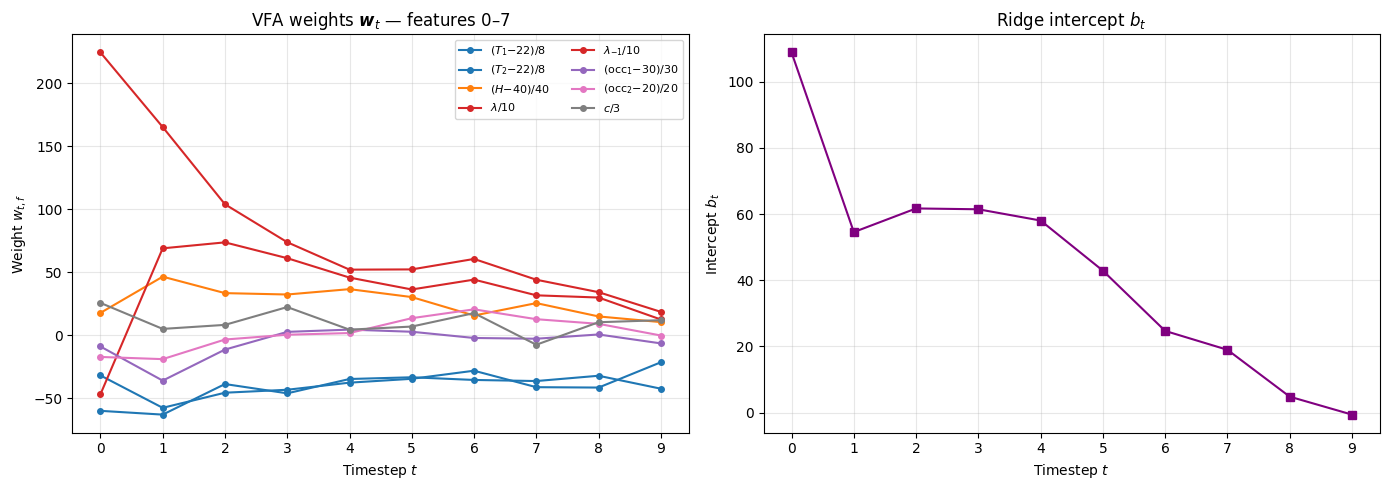

Saved: output/adp_weights_convergence.pdf


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ts   = np.arange(T)
lbls = ['$(T_1{-}22)/8$', '$(T_2{-}22)/8$', '$(H{-}40)/40$',
        '$\\lambda/10$', '$\\lambda_{-1}/10$',
        '$(\\mathrm{occ}_1{-}30)/30$', '$(\\mathrm{occ}_2{-}20)/20$', '$c/3$']
clr  = plt.cm.tab10(np.linspace(0, 0.7, N_FEAT))

for f in range(N_FEAT):
    ax1.plot(ts, eta_all[:T, f], marker='o', markersize=4,
             label=lbls[f], color=clr[f])
ax1.set_title('VFA weights $\\boldsymbol{w}_t$ — features 0–7')
ax1.set_xlabel('Timestep $t$')
ax1.set_ylabel('Weight $w_{t,f}$')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(ts)

ax2.plot(ts, eta_all[:T, N_FEAT], marker='s', color='purple')
ax2.set_title('Ridge intercept $b_t$')
ax2.set_xlabel('Timestep $t$')
ax2.set_ylabel('Intercept $b_t$')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(ts)

plt.tight_layout()
plt.savefig('output/adp_weights_convergence.pdf', bbox_inches='tight')
plt.show()
print("Saved: output/adp_weights_convergence.pdf")


## Verification

`ADP_policy_14.py` loads `output/adp_weights.json` at import time.
Running the cell below confirms the file is readable and the shapes are correct.

In [10]:
with open('output/adp_weights.json') as f:
    check = json.load(f)

print("JSON keys:", list(check.keys()))
print(f"Timesteps in 'eta': {sorted(check['eta'].keys())}")
print(f"Feature vector length per timestep: {len(check['eta']['0'])}")
print(f"  -> {N_FEAT} normalised feature weights  +  1 Ridge intercept  =  {N_FEAT+1}")
print()
print("Feature names stored in JSON:")
for i, name in enumerate(check['feature_names']):
    print(f"  [{i}]  {name}")
print()
print("ADP_policy_14.py loads this file at import time and calls select_action(state),")
print("which invokes solve_adp_step(state, ETA[t], params) at each decision epoch t.")


JSON keys: ['description', 'feature_names', 'eta']
Timesteps in 'eta': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Feature vector length per timestep: 9
  -> 8 normalised feature weights  +  1 Ridge intercept  =  9

Feature names stored in JSON:
  [0]  (T1-22)/8
  [1]  (T2-22)/8
  [2]  (H-40)/40
  [3]  price/10
  [4]  price_prev/10
  [5]  (occ1-30)/30
  [6]  (occ2-20)/20
  [7]  c/3
  [8]  intercept

ADP_policy_14.py loads this file at import time and calls select_action(state),
which invokes solve_adp_step(state, ETA[t], params) at each decision epoch t.
